# [기초-실습] 통계 101×데이터 분석: (9-10장) 가설검정의 주의점/인과와 상관

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## ⚙️ 환경 준비

### 1단계 · 한글 폰트 설치

- 그래프에 한글이 깨지지 않도록 나눔 폰트를 설치합니다.

- 실행 후 **[런타임] - [세션 다시 시작]**을 한 번 눌러야 폰트가 적용됩니다.

In [1]:
# 구글 코랩 환경에서 한글 폰트 설치 및 설정하기
# 필요시 아래 코드 실행 후, [런타임] - [세션 다시 시작] 후 셀을 다시 실행하세요.
!pip install statsmodels scikit-learn
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Sudo가 이 컴퓨터에서 사용하지 않도록 설정되어 있습니다. 사용하도록 설정하려면 으로 이동하세요. ]8;;ms-settings:developers\Developer Settings page]8;;\ 설정 앱의
Sudo가 이 컴퓨터에서 사용하지 않도록 설정되어 있습니다. 사용하도록 설정하려면 으로 이동하세요. ]8;;ms-settings:developers\Developer Settings page]8;;\ 설정 앱의
'rm'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


### 2단계 · 라이브러리 불러오기

- 이번 실습에서 쓰는 도구입니다. **한 번만 실행**해 두면 끝까지 사용합니다.

- `TTestIndPower`는 검정력·표본크기를 계산하는 클래스, `NearestNeighbors`는 경향점수가 가장 가까운
  짝을 찾아주는 도구입니다.

In [3]:
# 파이썬 라이브러리 및 모듈 가져오기
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.power import TTestIndPower
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

---

# 가설검정의 주의점

> p-값 하나로 결론을 내리면 무엇을 놓치는지, 그리고 "유의한 결과"가 어떻게 **만들어질 수 있는지**를 봅니다.

## 문제 1 · 펭귄 두 종의 몸무게는 정말 다를까?

`난이도 하` · `예상 20분`

**📖 상황**

- 7장에서 Adelie 수컷만 골라 회귀했을 때 p-값이 0.05를 넘어 **기각에 실패**했습니다.
  그때 우리는 "표본이 작아서"라고 정리했습니다.

- 이제 반대편에서 물어봅니다. **표본을 아주 크게 만들면 어떤 일이 벌어질까요?**

- 실제 팔머 기지 데이터에서 Adelie와 Chinstrap의 몸무게는 평균 **32g**밖에 차이나지 않습니다.
  펭귄 한 마리 몸무게(약 3,700g)의 **1%도 안 되는** 차이입니다.

- 이 32g을 붙잡고 표본만 늘려 가면, p-값은 어디까지 내려갈까요?

**🎯 이 문제로 배우는 것**

- **"표본크기 n이 커지면 p-값은 작아진다"**는 강의 9장의 명제를 실제 데이터로 확인하고,
  그래서 **효과크기(Effect Size)**를 함께 봐야 하는 이유를 숫자로 이해합니다.

In [4]:
# 문제 1 · 데이터 준비 — 실행만 하세요
penguins = sns.load_dataset('penguins')
mass = penguins.dropna(subset=['body_mass_g', 'species'])

adelie    = mass.loc[mass['species'] == 'Adelie',    'body_mass_g']
chinstrap = mass.loc[mass['species'] == 'Chinstrap', 'body_mass_g']

print("Adelie    n=%3d   평균 %.1f g   표준편차 %.1f g" % (len(adelie),    adelie.mean(),    adelie.std(ddof=1)))
print("Chinstrap n=%3d   평균 %.1f g   표준편차 %.1f g" % (len(chinstrap), chinstrap.mean(), chinstrap.std(ddof=1)))

diff_g = adelie.mean() - chinstrap.mean()
print("\n두 종의 평균 차이: %.1f g  (Adelie 몸무게의 약 %.1f%%)" % (diff_g, abs(diff_g) / adelie.mean() * 100))

Adelie    n=151   평균 3700.7 g   표준편차 458.6 g
Chinstrap n= 68   평균 3733.1 g   표준편차 384.3 g

두 종의 평균 차이: -32.4 g  (Adelie 몸무게의 약 0.9%)


### Q1 · 두 종의 몸무게를 t-검정으로 비교해 봅시다

- `adelie`와 `chinstrap`의 몸무게에 대해 **이표본 t-검정(Two-sample t-Test)**을 수행하세요.
  5-6장 실습에서 쓴 그 검정입니다.

- 유의수준 0.05를 기준으로 **"기각한다 / 기각하지 못한다"까지 문장으로 출력**하세요.

- `💡 힌트` `stats.ttest_ind(x, y)`는 통계량과 p-값을 함께 돌려줍니다.

In [5]:
# 문제 1 · Q1
from scipy import stats

t_stat, p_value = stats.ttest_ind(adelie, chinstrap)

alpha = 0.05
if p_value < alpha:
    print(f"p-값({p_value:.4f}) < 0.05 이므로, 귀무가설을 기각한다.")
else:
    print(f"p-값({p_value:.4f}) >= 0.05 이므로, 귀무가설을 기각하지 못한다.")

p-값(0.6119) >= 0.05 이므로, 귀무가설을 기각하지 못한다.


### Q2 · 효과크기(Cohen's d)를 직접 계산해 봅시다

- 강의 9장의 공식대로 `cohen_d(x, y)` **함수를 직접 만드세요. Q3에서 계속 씁니다.**
  - 분자: 두 집단 평균의 차이
  - 분모: 통합 표준편차 $s = \sqrt{\dfrac{(n_A-1)s_A^2 + (n_B-1)s_B^2}{n_A + n_B - 2}}$

- 만든 함수로 `adelie`와 `chinstrap`의 효과크기를 계산해 출력하세요.

- Cohen의 관례적 기준(0.2 작음 / 0.5 중간 / 0.8 큼)에서 어디에 놓이는지도 함께 적으세요.

- `💡 힌트` 표본표준편차는 `np.std(x, ddof=1)`, 표본 수는 `len(x)`입니다.

In [6]:
# 문제 1 · Q2
def cohen_d(x, y):
    n_a, n_b = len(x), len(y)
    s_a, s_b = np.std(x, ddof=1), np.std(y, ddof=1)
    pooled_std = np.sqrt(((n_a - 1) * s_a**2 + (n_b - 1) * s_b**2) / (n_a + n_b - 2))
    return (np.mean(x) - np.mean(y)) / pooled_std

d = cohen_d(adelie, chinstrap)
print(f"Cohen's d = {d:.4f}")

Cohen's d = -0.0742


### Q3 · 표본을 늘려 가며 p-값과 효과크기를 함께 추적해 봅시다

- Q1에서 본 두 종의 평균과 통합 표준편차를 **모집단 참값**으로 삼습니다.
  즉 "실제로 32g 차이가 나는 두 집단"에서 표본을 뽑는 상황을 만듭니다.

- `n = 30, 150, 1000, 5000, 20000` 각각에 대해, 두 집단에서 n마리씩 뽑아
  **t-검정과 Cohen's d를 400번 반복**하세요.

- 각 n마다 다음 세 값을 표로 정리해 출력하세요.
  **① p-값의 중위수 ② p < 0.05가 나온 비율(%) ③ Cohen's d의 평균**

- `💡 힌트` 모집단 참값은 이렇게 잡습니다.

  ```
  MU_A, MU_C = adelie.mean(), chinstrap.mean()
  SIGMA = np.sqrt(((len(adelie)-1)*adelie.std(ddof=1)**2 + (len(chinstrap)-1)*chinstrap.std(ddof=1)**2)
                  / (len(adelie) + len(chinstrap) - 2))
  ```

- `💡 힌트` 표본 추출은 `rng = np.random.default_rng(7)`로 시작해 `rng.normal(MU_A, SIGMA, n)`.
  결과는 리스트에 모아 `pd.DataFrame`으로 만들면 보기 좋습니다.

In [7]:
# 문제 1 · Q3
MU_A, MU_C = adelie.mean(), chinstrap.mean()
SIGMA = np.sqrt(((len(adelie)-1)*adelie.std(ddof=1)**2 +
                 (len(chinstrap)-1)*chinstrap.std(ddof=1)**2)
                / (len(adelie) + len(chinstrap) - 2))

rng = np.random.default_rng(7)
n_list = [30, 150, 1000, 5000, 20000]
n_repeat = 400

rows = []
for n in n_list:
    p_values, d_values = [], []
    for _ in range(n_repeat):
        sample_a = rng.normal(MU_A, SIGMA, n)
        sample_c = rng.normal(MU_C, SIGMA, n)
        t_stat, p_val = stats.ttest_ind(sample_a, sample_c)
        d_values.append(cohen_d(sample_a, sample_c))
        p_values.append(p_val)
    p_values = np.array(p_values)
    rows.append({
        'n': n,
        'p-값 중위수': np.median(p_values),
        'p<0.05 비율(%)': (p_values < 0.05).mean() * 100,
        "Cohen's d 평균": np.mean(d_values)
    })

result = pd.DataFrame(rows)
print(result.to_string(index=False))

    n      p-값 중위수  p<0.05 비율(%)  Cohen's d 평균
   30 4.668099e-01          5.75     -0.080738
  150 4.421423e-01          9.50     -0.068576
 1000 8.407337e-02         39.25     -0.075479
 5000 1.578511e-04         95.50     -0.074863
20000 1.312322e-13        100.00     -0.074020


### Q4 · 결과를 그래프로 그려 봅시다

- 가로축을 **표본크기 n**으로, 두 그림을 **나란히** 그리세요.
  - 왼쪽: n에 따른 **p < 0.05 비율(%)**
  - 오른쪽: n에 따른 **Cohen's d 평균**

- n이 30에서 20,000까지 넓게 퍼져 있으니 **가로축을 로그 스케일**로 두면 잘 보입니다.

- `💡 힌트` `fig, ax = plt.subplots(1, 2, figsize=(12, 4))` / `ax[0].set_xscale('log')`

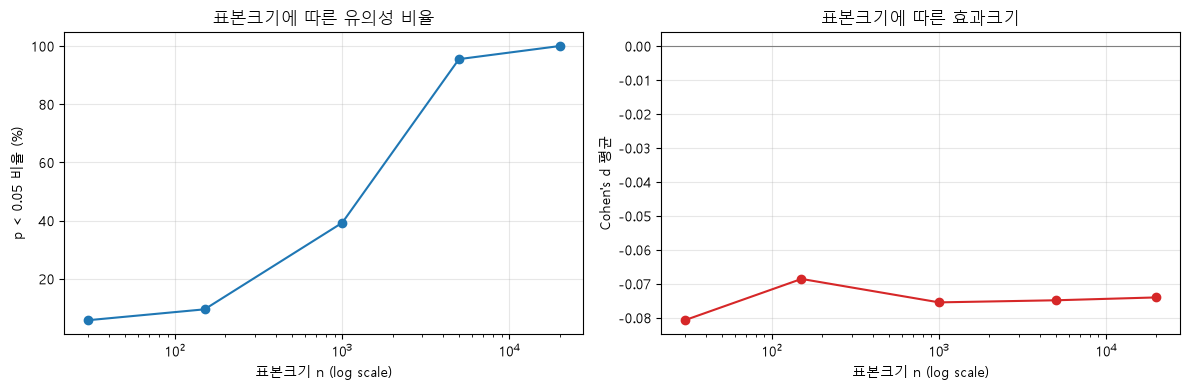

In [ ]:
# 문제 1 · Q4
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# 왼쪽: n에 따른 p < 0.05 비율(%)
ax[0].plot(result['n'], result['p<0.05 비율(%)'], marker='o', color='tab:blue')
ax[0].set_xscale('log')
ax[0].set_xlabel('표본크기 n (log scale)')
ax[0].set_ylabel('p < 0.05 비율 (%)')
ax[0].set_title('표본크기에 따른 유의성 비율')
ax[0].grid(alpha=0.3)

# 오른쪽: n에 따른 Cohen's d 평균
ax[1].plot(result['n'], result["Cohen's d 평균"], marker='o', color='tab:red')
ax[1].set_xscale('log')
ax[1].set_xlabel('표본크기 n (log scale)')
ax[1].set_ylabel("Cohen's d 평균")
ax[1].set_title("표본크기에 따른 효과크기")
ax[1].axhline(0, color='gray', linewidth=0.8)
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 💬 정리 · 결과를 말로 설명해 보기

- Q1에서 두 종의 몸무게는 통계적으로 유의한 차이가 **없었습니다.** 그런데 Q3에서 n=5,000일 때는
  95% 이상 유의하게 나왔습니다. **같은 32g인데 결론이 갈린 이유**는 무엇인가요?

- Q3의 표에서 n이 커질 때 **p-값**은 어떻게 변했나요? **Cohen's d**는 어떻게 변했나요?
  이 대비가 뜻하는 바를 한 문장으로 정리해 보세요.

- "통계적으로 유의하다"와 "실질적으로 의미 있다"는 같은 말인가요? 펭귄 32g을 예로 설명해 보세요.

- A/B 테스트에서 버튼 색을 바꿨더니 클릭률이 0.1%p 올랐고 p-값은 0.001이었습니다.
  이 결과만으로 버튼을 바꿔야 한다고 말할 수 있을까요?

- 논문이나 보고서에 **p-값만** 적는 것이 왜 부족한가요? 무엇을 함께 적어야 할까요?

<details>
<summary>(클릭) 💡 생각의 갈피</summary>

- 강의 9장은 이렇게 적었습니다 — _"표본크기 𝓃이 커지면 𝑝값은 작아지므로 검출하고자 하는 효과크기를
  사전에 설정하고 표본크기 𝓃을 설계해야 합니다."_ Q3의 표가 이 문장을 그림으로 옮긴 것입니다.

- p-값은 **"차이가 있는가"**에 답하고, 효과크기는 **"그 차이가 얼마나 큰가"**에 답합니다.
  Q3의 표에서 어느 열이 어느 질문에 답하는지 나눠 보세요. 한 열은 n에 따라 움직이고, 다른 한 열은 꼼짝하지 않습니다.

- 32g은 Adelie 몸무게의 0.9%입니다. 저울의 눈금 하나 차이를 두고 "종에 따라 몸무게가 다르다"고
  보고서에 쓸 수 있을지 생각해 보세요.

- 마지막 질문의 답을 미국통계협회(ASA)는 2016년에 성명으로 내놓았습니다.
  요지는 "p-값 하나로 과학적 결론을 대신하지 말라"는 것이었습니다.

</details>

In [ ]:
# 문제 1 · 정리
# 여기에 의견을 작성해주세요.

[1번 문제]
- Q1과 Q3에서 결론이 다르게 나온 건 표본크기가 달랐기 때문이다. Q1은 실제 팔머 데이터(n=151, 68)로 검정했는데, 이 정도 표본에서는 32g이라는 차이가 표준편차에 묻힐 만큼 작아서 "유의하지 않다"는 결과가 나왔다. 반면 Q3에서는 32g 차이가 나는 모집단을 그대로 두고 표본만 늘려서 뽑았더니, 똑같은 32g 차이인데도 95% 이상 유의하게 나왔다. 즉 차이의 실제 크기는 전혀 안 변했는데, 표본을 충분히 키우면 그 작은 차이조차 "우연이 아니다"라고 검출할 수 있는 통계적 힘 즉 검정력이 생긴 것이다. 결론이 달라진 건 차이가 커진 게 아니라, 그 차이를 잡아낼 수 있는 표본의 정밀도가 달라졌기 때문이다.

[2번 문제]
- Q3의 표를 보면 n이 20,000으로 커지는 동안 p-값의 중위수는 0.47 근처에서 0.0000까지 계속 떨어졌고, p<0.05 비율은 5.75%에서 100%까지 올랐다. 반면 Cohen's d의 평균은 -0.07~-0.08 사이에서 거의 움직이지 않았다. 이는, p-값은 표본크기에 따라 얼마든지 작아질 수 있는 값이고, 효과크기는 표본크기와 무관하게 모집단이 가진 실제 차이의 크기를 보여주는 값이라는 것이다. 따라서 표본크기가 커지면 커질수록 p-값만 보고 판단하는 건 위험해지고, 반드시 효과크기를 함께 봐야 한다.

[3번 문제]
- 전혀 다른 말이다. "통계적으로 유의하다"는 그 차이가 순전히 우연만으로 생겼을 가능성이 낮다는 뜻이고, "실질적으로 의미 있다"는 그 차이의 크기가 우리가 신경 써야 할 만큼 실제로 중요하냐는 뜻이다. 펭귄 사례로 얘기를 해보자면, 32g은 Adelie 몸무게의 0.9%밖에 안 되는 차이라서, 생물학적으로든 실무적으로든 "이 종은 확실히 더 무겁다"고 말하기엔 무의미한 수준이지만, 표본을 20,000까지 늘리면 이 무의미한 차이도 p<0.05로 "통계적으로 유의"해질 수 있었다. 그러니 유의하다는 것이 곧 중요하다는 뜻은 아닙니다.

[4번 문제]
- 이것만으로는 판단할 수 없다. p값은 이 차이가 우연일 가능성이 낮다는 것만 말해줄 뿐, 그 0.1%p라는 차이가 그만한 가치가 있는지는 말해주지 않는다. 만약 이 테스트도 표본이 아주 컸다면, 펭귄 사례처럼 실질적으로는 미미한 차이도 유의하게 나왔을 수 있다. 버튼을 바꾸려면 0.1%가 실제 매출이나 전환에 미치는 영향(효과크기, 예상 이익)을 같이 따져보고, 그 개선이 버튼 교체에 드는 비용이나 리스크보다 큰지를 봐야 합니다.

[5번 문제]
- p-값 하나만 적으면 "차이가 있는지 없는지"에 대한 답은 되지만, "그 차이가 얼마나 큰지, 실제로 중요한지"에 대한 정보는 전혀 담기지 않기 때문이다. 미국통계협회(ASA)가 2016년 성명에서 밝힌 것처럼, p-값 하나로 과학적 결론이나 정책적 결정을 대신해서는 안 된다. 

## 문제 2 · 그럼 몇 마리를 재야 할까?

`난이도 중` · `예상 25분`

**📖 상황**

- 문제 1은 "n을 늘리면 유의해진다"를 보여줬습니다. 뒤집어 읽으면 무서운 말입니다 —
  **n이 모자라면 진짜 있는 차이도 놓친다.**

- 진짜 차이가 있는데 놓치는 잘못을 **제2종 오류(β)**라 하고, 놓치지 않을 확률 **1 − β**를
  **검정력(Power)**이라 부릅니다. 관례적으로 80%를 목표로 삼습니다.

- 강의 9장은 이렇게 못박습니다 — _"미리 검출하고자 하는 효과크기를 정하고, 설정한 𝛼와 𝛽에 따라
  필요한 표본크기 𝓃을 결정해야 합니다."_

- 이번 문제는 그 계산을 **직접** 해 봅니다. 실험을 **시작하기 전에** 하는 계산입니다.

**🎯 이 문제로 배우는 것**

- 제1종·제2종 오류를 구분하고, **효과크기 → 필요 표본수**를 산출하는 검정력 분석을 익힙니다.
  문제 1의 시뮬레이션 결과가 이론값과 맞는지도 확인합니다.

In [10]:
# 문제 2 · 데이터 준비 — 실행만 하세요
# 문제 1의 Q2·Q3를 먼저 완료해야 이 문제를 풀 수 있습니다.

analysis = TTestIndPower()   # 검정력 분석 도구

print("검정력 분석에 쓰이는 네 개의 값")
print("  ① 유의수준 alpha  — 제1종 오류를 허용하는 한계 (보통 0.05)")
print("  ② 검정력 power    — 1 - beta, 진짜 차이를 잡아낼 확률 (보통 0.80)")
print("  ③ 효과크기 d      — 검출하고자 하는 차이의 크기")
print("  ④ 표본크기 nobs1  — 집단당 표본 수")
print("\n→ 이 중 셋을 정하면 나머지 하나가 결정됩니다.")

검정력 분석에 쓰이는 네 개의 값
  ① 유의수준 alpha  — 제1종 오류를 허용하는 한계 (보통 0.05)
  ② 검정력 power    — 1 - beta, 진짜 차이를 잡아낼 확률 (보통 0.80)
  ③ 효과크기 d      — 검출하고자 하는 차이의 크기
  ④ 표본크기 nobs1  — 집단당 표본 수

→ 이 중 셋을 정하면 나머지 하나가 결정됩니다.


### Q1 · 두 가지 오류를 표로 정리해 봅시다

- 강의 9장의 신약 예시를 씁니다. **H₀: "신약은 효과가 없다"**

- 아래 네 칸을 채우세요. 각 칸에 **오류의 이름**과 **무엇을 잃는가**를 함께 적으세요.

- 코드가 아니라 **말로** 채우는 문제입니다.

In [11]:
# 문제 2 · Q1
#                          | H0를 기각함 (효과가 있다고 결론)  | H0를 기각 못함 (효과가 없다고 결론)
# 실제로 효과가 없을 때     | 제1종 오류 (α) | 맞는 결론
# 실제로 효과가 있을 때     | 맞는 결론 | 제2종 오류 (β)
#
# 제1종 오류(alpha)를 범하면 무엇을 잃나요?: 실제로는 효과가 없는 신약인데 "효과가 있다"고 잘못 판단해서, 효과 없는 약을 세상에 내놓게 됩니다.
# 제2종 오류(beta)를 범하면 무엇을 잃나요?: 실제로는 효과가 있는 신약인데 "효과가 없다"고 놓쳐버려서, 진짜 도움이 될 수 있었던 치료제를 폐기하게 됩니다.
# 검정력(1-beta)을 한 문장으로 정의하면?: 실제로 효과가 있을 때, 그 효과를 통계적으로 제대로 잡아내어 "효과가 있다"고 옳게 결론 내릴 확률

### Q2 · 문제 1의 시뮬레이션이 이론과 맞는지 확인해 봅시다

- 문제 1에서 구한 펭귄의 효과크기(d ≈ 0.074)에 대해, `n = 30, 150, 1000, 5000, 20000`
  각각의 **이론적 검정력**을 계산하세요.

- 이 값을 문제 1 Q3의 **'p < 0.05 비율'과 나란히 출력**해 두 값이 일치하는지 눈으로 확인하세요.

- `💡 힌트` `analysis.power(effect_size=..., nobs1=..., alpha=0.05, ratio=1)`
  — `effect_size`에는 효과크기의 **절대값**을 넣습니다.

In [12]:
# 문제 2 · Q2
from statsmodels.stats.power import TTestIndPower
import pandas as pd

analysis = TTestIndPower()
d_penguin = 0.0742  # 문제 1에서 구한 값
n_list = [30, 150, 1000, 5000, 20000]

rows = []
for n in n_list:
    power = analysis.power(effect_size=abs(d_penguin), nobs1=n, alpha=0.05, ratio=1)
    rows.append({'n': n, '이론적 검정력(%)': power * 100})

result_q2 = pd.DataFrame(rows)
result_q2['시뮬레이션 p<0.05 비율(%)'] = [5.75, 9.50, 39.25, 95.50, 100.00]

print(result_q2.to_string(index=False))

    n  이론적 검정력(%)  시뮬레이션 p<0.05 비율(%)
   30    5.920125                5.75
  150    9.816530                9.50
 1000   38.162713               39.25
 5000   95.991320               95.50
20000   99.999998              100.00


### Q3 · 80% 검정력에 필요한 표본수를 구해 봅시다

- 유의수준 0.05, 검정력 0.80을 목표로 할 때 **집단당 필요한 표본수**를 구하세요.

- 효과크기 네 가지에 대해 각각 계산해 표로 출력하세요.
  **① 펭귄의 d ≈ 0.074 ② 0.2(작음) ③ 0.5(중간) ④ 0.8(큼)**

- `💡 힌트` `analysis.solve_power(effect_size=..., alpha=0.05, power=0.8)`
  — 사람 수는 소수점이 될 수 없으니 `np.ceil()`로 올림하세요.

In [13]:
# 문제 2 · Q3
effect_sizes = {
    '펭귄 d≈0.074': 0.0742,
    '0.2 (작음)': 0.2,
    '0.5 (중간)': 0.5,
    '0.8 (큼)': 0.8
}

rows = []
for label, d in effect_sizes.items():
    n_required = analysis.solve_power(effect_size=d, alpha=0.05, power=0.8)
    rows.append({'효과크기': label, 'd 값': d, '집단당 필요 표본수': int(np.ceil(n_required))})

result_q3 = pd.DataFrame(rows)
print(result_q3.to_string(index=False))

      효과크기    d 값  집단당 필요 표본수
펭귄 d≈0.074 0.0742        2853
  0.2 (작음) 0.2000         394
  0.5 (중간) 0.5000          64
   0.8 (큼) 0.8000          26


### Q4 · 검정력 곡선을 그려 봅시다

- 효과크기를 **d = 0.5로 고정**하고, 집단당 표본수 n을 5부터 200까지 바꿔가며
  **검정력 곡선**을 그리세요.

- **80% 기준선**을 수평선으로 함께 그려, 곡선이 이 선을 넘는 지점이 Q3에서 구한 값과
  맞는지 확인하세요.

- `💡 힌트` `n_list = np.arange(5, 201, 5)` / `plt.axhline(0.8, color='red', linestyle='--')`

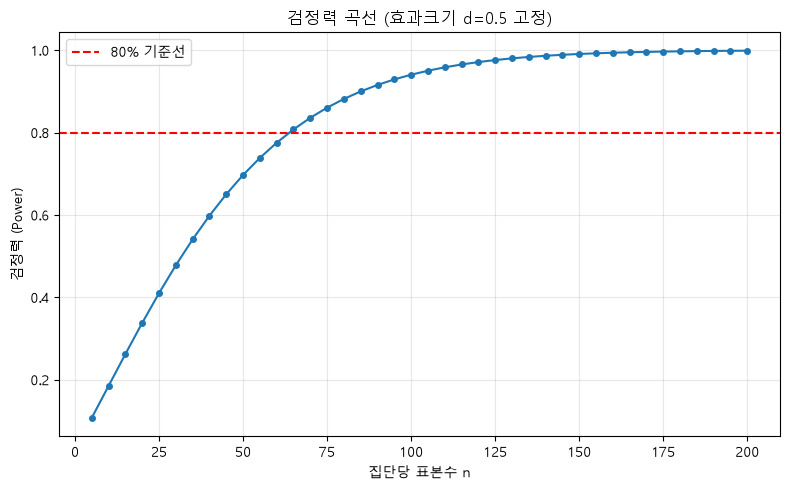

In [14]:
# 문제 2 · Q4
d_fixed = 0.5
n_list = np.arange(5, 201, 5)
power_values = [analysis.power(effect_size=d_fixed, nobs1=n, alpha=0.05, ratio=1) for n in n_list]

plt.figure(figsize=(8, 5))
plt.plot(n_list, power_values, marker='o', markersize=4, color='tab:blue')
plt.axhline(0.8, color='red', linestyle='--', label='80% 기준선')
plt.xlabel('집단당 표본수 n')
plt.ylabel('검정력 (Power)')
plt.title("검정력 곡선 (효과크기 d=0.5 고정)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 💬 정리 · 결과를 말로 설명해 보기

- Q3에서 펭귄의 32g 차이(d ≈ 0.074)를 80% 검정력으로 잡으려면 집단당 몇 마리가 필요했나요?
  팔머 기지 데이터는 **전체가 344마리**입니다. 이 연구는 애초에 가능했을까요?

- 검정력이 낮은 연구에서 "유의한 차이가 없었다"는 결과가 나왔을 때, 우리는 무엇을 알 수 있고
  **무엇을 알 수 없나요?** (7장 문제 4 Q5의 Adelie 수컷 회귀를 떠올려 보세요)

- 실험을 **시작하기 전에** 표본수를 정해야 하는 이유는 무엇인가요?
  데이터를 본 **뒤에** 정하면 무엇이 잘못될까요?

- 유의수준 alpha를 0.05에서 0.01로 낮추면 필요한 n은 늘어날까요, 줄어들까요?
  Q3의 코드를 고쳐 **직접 계산해** 확인해 보세요.

- "검출하고자 하는 효과크기를 얼마로 정할 것인가"는 **통계 문제**인가요, **도메인 문제**인가요?

<details>
<summary>(클릭) 💡 생각의 갈피</summary>

- 네 개 값(alpha, beta, 효과크기, n) 중 **셋을 정하면 나머지 하나가 결정됩니다.**
  `solve_power`가 하는 일이 바로 이 방정식을 푸는 것입니다. 무엇을 미지수로 둘지 바꿔 보세요.

- **"유의한 차이 없음"은 "차이 없음"이 아닙니다.** 검정력이 20%인 연구라면, 진짜 차이가 있어도
  5번 중 4번은 놓칩니다. 그런 연구의 "차이 없음"은 증거라기보다 **정보 부족**입니다.

- 세 번째 질문의 답이 곧 다음 문제(p-해킹)의 출발점입니다. 표본수를 데이터를 보고 정한다는 것은
  곧 **결과를 보고 규칙을 바꾼다**는 뜻입니다.

- 마지막 질문 — 고혈압 치료제에서 "혈압을 몇 mmHg 낮추면 임상적으로 의미 있는가"를 정하는 사람은
  통계학자인가요, 의사인가요? 통계는 그 숫자를 **받아서** n을 계산해 줄 뿐입니다.

</details>

In [ ]:
# 문제 2 · 정리
# 여기에 의견을 작성해주세요.

[1번 문제]
- Q3에서 계산한 결과, d≈0.074를 80% 검정력으로 잡아내려면 집단당 2,853마리가 필요하다. 그러나 펭귄 데이터는 전체가 344마리(Adelie: 151, Chinstrap: 68)에 불과하다. 즉 이 연구는 애초에 32g 차이의 존재 여부를 확실히 가릴 만한 검정력을 갖추지 못한 채로 설계되었다.

[2번 문제]
- 알 수 있는 것은 "이 표본에서는 통계적으로 차이를 확증하지 못했다"는 사실뿐이다. 알 수 없는 것은 "실제로 차이가 없다"는 사실이다. 검정력이 낮으면(예: 20%), 실제로 차이가 존재해도 이를 놓칠 확률이 80%에 달한다. 7장 문제4 Q5의 Adelie 수컷 회귀에서 p>0.05가 나온 경우도, "관계가 없다"는 증거가 아니라 "이 표본으로는 확인하지 못했다"는 정보 부족 상태였을 가능성이 높다. "유의하지 않음"을 "차이 없음"으로 해석해서는 안 된다.

[3번 문제]
- 표본수를 미리 정해야 하는 이유는, 그래야 유의수준이 의도한 수준(5%)으로 유지되기 때문이다. 데이터를 이미 확인한 뒤에 표본을 더 모을지, 언제 멈출지를 결정한다면, 이는 원하는 결과가 나올 때까지 표본을 조정하는 것과 다름없어 실제 제1종 오류율이 5%보다 훨씬 커질 것이다. 

[4번 문제]
- 직접 계산한 결과, d≈0.074와 검정력 80% 기준으로 alpha=0.05일 때는 2,853명이 필요했고, alpha=0.01로 낮추자 4,245명으로 늘어났다. alpha를 더 엄격하게 설정할수록 우연으로 오인할 여지를 줄여야 하므로, 그만큼 더 많은 표본이 요구되는 것이다. 이 결과는 alpha·beta·효과크기·n 네 값이 서로 얽혀 있음을 다시 한번 보여준다.

[5번 문제]
- 도메인 문제이다. 통계학과 solve_power 같은 도구는 효과크기·alpha·power·n 중 셋이 주어지면 나머지 하나를 계산해줄 뿐이다. "얼마만큼의 차이가 실제로 의미 있는 차이인가"를 정하는 것은 해당 분야 전문가의 몫이다. 

## 문제 3 · 유의한 결과는 '만들어질' 수 있다

`난이도 중` · `예상 25분`

**📖 상황**

- 심리학 분야의 과거 연구 100건을 재실험한 결과, 원래 유의했던 97건 중 **36건만** 다시
  유의했습니다(강의 9장). 이것이 **재현성 위기(Reproducibility Crisis)**입니다.

- 원인 중 하나는 **p-해킹** — 의도했든 아니든 p-값을 0.05 아래로 밀어 넣는 행위입니다.

- 이번 문제는 **아무 차이도 없는 두 집단**을 놓고, 분석 방식만 바꿔가며
  "유의한 결과"를 얼마나 만들어낼 수 있는지 **직접 세어 봅니다.**

- 진짜 차이가 없으므로 유의하다는 결론은 **전부 제1종 오류**입니다.
  절차를 지켰다면 5%여야 합니다.

**🎯 이 문제로 배우는 것**

- **정직한 분석 / 표본 추가형 / 다중비교형** 세 가지의 제1종 오류율을 직접 세어 비교하고,
  다중비교 보정이 왜 필요한지 확인합니다.

In [20]:
# 문제 3 · 데이터 준비 — 실행만 하세요
N_SIM = 1000     # 시뮬레이션 반복 횟수
SEED  = 777      # 난수 시드 — Q1~Q4에서 각각 이 값으로 시작하면 몇 번 재실행해도 같은 결과가 나옵니다

print("이번 문제의 전제")
print("  두 집단 A, B는 모두 N(0, 1)에서 나옵니다 → 진짜 차이는 정확히 0")
print("  즉 귀무가설이 '참'인 상황이며, 유의하다는 결론은 모두 제1종 오류입니다.")
print("  절차를 지켰다면 오류율은 유의수준 5% 근처여야 합니다.")
print("\n각 조건마다 %d번씩 반복해 '유의하다고 결론 내린 비율'을 셉니다." % N_SIM)

이번 문제의 전제
  두 집단 A, B는 모두 N(0, 1)에서 나옵니다 → 진짜 차이는 정확히 0
  즉 귀무가설이 '참'인 상황이며, 유의하다는 결론은 모두 제1종 오류입니다.
  절차를 지켰다면 오류율은 유의수준 5% 근처여야 합니다.

각 조건마다 1000번씩 반복해 '유의하다고 결론 내린 비율'을 셉니다.


### Q1 · 정직한 분석의 제1종 오류율을 확인해 봅시다

- **기준선**을 먼저 만듭니다. 각 집단에서 **20명씩 뽑아 딱 한 번만** t-검정하세요.

- 이것을 `N_SIM`번 반복해 **p < 0.05가 나온 비율**을 출력하세요.

- 이 값이 유의수준 0.05와 가까운지 확인하세요.

- `💡 힌트` 셀 맨 위에서 `rng = np.random.default_rng(SEED)`로 시작하세요.
  이렇게 하면 셀을 몇 번 다시 실행해도 같은 결과가 나옵니다. **Q2~Q4도 모두 이렇게 시작합니다.**

- `💡 힌트` `rng.normal(0, 1, 20)`으로 표본을 만들고, `for`문으로 반복해 세면 됩니다.

In [21]:
# 문제 3 · Q1
import numpy as np
from scipy import stats

N_SIM = 1000
SEED = 777
rng = np.random.default_rng(SEED)

significant_count = 0
for _ in range(N_SIM):
    group_a = rng.normal(0, 1, 20)
    group_b = rng.normal(0, 1, 20)
    t_stat, p_val = stats.ttest_ind(group_a, group_b)
    if p_val < 0.05:
        significant_count += 1

error_rate_q1 = significant_count / N_SIM
print(f'Q1. 정직한 분석의 제1종 오류율: {error_rate_q1:.4f} ({error_rate_q1*100:.1f}%)')

Q1. 정직한 분석의 제1종 오류율: 0.0490 (4.9%)


### Q2 · 해킹 ① — 결과를 보고 표본을 더 모으면

- 강의 9장이 첫 번째로 꼽은 p-해킹입니다 — _"결과를 보며 표본크기를 늘려서는 안 됨"_

- 다음 규칙을 따르는 'p-해커'를 만드세요.
  1. 각 집단 **20명**으로 시작해 t-검정
  2. **p < 0.05면 "찾았다!"** 하고 즉시 멈춤
  3. **p ≥ 0.05면 각 집단에 10명씩 추가**해 다시 검정
  4. 이 과정을 **최대 5번**까지 반복

- `N_SIM`번 반복해 **한 번이라도 p < 0.05를 얻은 비율**을 출력하고, Q1의 값과 비교하세요.

- `💡 힌트` `rng = np.random.default_rng(SEED)`로 시작하세요.
  '해커 한 명'을 함수로 만들어 두면 반복이 깔끔해집니다.
  표본을 `list`로 두면 `.extend()`로 이어붙일 수 있습니다.

In [22]:
# 문제 3 · Q2
def p_hacker_sample_add(rng):
    group_a = list(rng.normal(0, 1, 20))
    group_b = list(rng.normal(0, 1, 20))

    for attempt in range(5):
        t_stat, p_val = stats.ttest_ind(group_a, group_b)
        if p_val < 0.05:
            return True  # '찾았다!'
        group_a.extend(rng.normal(0, 1, 10))
        group_b.extend(rng.normal(0, 1, 10))
    return False

found_count = 0
for _ in range(N_SIM):
    if p_hacker_sample_add(rng):
        found_count += 1

error_rate_q2 = found_count / N_SIM
print(f'Q2. 표본 추가형 해킹의 제1종 오류율: {error_rate_q2:.4f} ({error_rate_q2*100:.1f}%)')

Q2. 표본 추가형 해킹의 제1종 오류율: 0.1320 (13.2%)


### Q3 · 해킹 ② — 지표를 20개 재서 하나만 보고하면

- 강의 9장의 두 번째 p-해킹입니다 — _"마음에 드는 해석만 보고해서는 안 됨"_

- 이번엔 표본을 추가하지 않습니다. 대신 **아무 차이 없는 지표 20개**를 각각 20명씩 검정하고,
  **하나라도 유의하면 그것만 보고**합니다.

- `N_SIM`번 반복해 성공률을 출력하세요.

- 이론값 **1 − 0.95²⁰**과 나란히 출력해 비교하세요.

- `💡 힌트` `rng = np.random.default_rng(SEED)`로 시작하세요.
  바깥 `for`문은 시뮬레이션 반복, 안쪽 `for`문은 20개 지표입니다.
  `any()`를 쓰면 짧게 쓸 수 있습니다.

In [23]:
# 문제 3 · Q3
found_count = 0
for _ in range(N_SIM):
    p_values = []
    for _ in range(20):  # 아무 차이 없는 지표 20개
        group_a = rng.normal(0, 1, 20)
        group_b = rng.normal(0, 1, 20)
        t_stat, p_val = stats.ttest_ind(group_a, group_b)
        p_values.append(p_val)
    if any(p < 0.05 for p in p_values):
        found_count += 1

error_rate_q3 = found_count / N_SIM
theoretical = 1 - 0.95**20
print(f'Q3. 다중비교형 해킹의 제1종 오류율: {error_rate_q3:.4f} ({error_rate_q3*100:.1f}%)')
print(f'이론값 1 - 0.95^20        : {theoretical:.4f} ({theoretical*100:.1f}%)')

Q3. 다중비교형 해킹의 제1종 오류율: 0.6530 (65.3%)
이론값 1 - 0.95^20        : 0.6415 (64.2%)


### Q4 · 세 결과를 나란히 놓고, 보정 효과까지 확인해 봅시다

- Q3의 방식에 **본페로니 보정**을 적용하면 오류율이 어떻게 되는지 계산하세요.
  (지표가 20개이므로 각 검정의 기준을 `0.05 / 20`으로 낮춥니다)

- Q1 ~ Q3 결과와 보정 후 결과, 총 **네 개를 막대그래프**로 그리세요.

- **α = 5% 기준선**을 수평선으로 함께 표시해 어느 것이 선을 넘는지 한눈에 보이게 하세요.

- `💡 힌트` 보정 후 계산도 `rng = np.random.default_rng(SEED)`로 시작하세요.
  Q3의 코드에서 기준값만 `0.05 / 20`으로 바꾸면 됩니다.

- `💡 힌트` `plt.bar(라벨리스트, 값리스트)` / `plt.axhline(5, color='red', linestyle='--')`

In [24]:
# 문제 3 · Q4
alpha_corrected = 0.05 / 20  # 본페로니 보정

found_count = 0
for _ in range(N_SIM):
    p_values = []
    for _ in range(20):
        group_a = rng.normal(0, 1, 20)
        group_b = rng.normal(0, 1, 20)
        t_stat, p_val = stats.ttest_ind(group_a, group_b)
        p_values.append(p_val)
    if any(p < alpha_corrected for p in p_values):
        found_count += 1

error_rate_q4 = found_count / N_SIM
print(f'Q4. 본페로니 보정 후 제1종 오류율: {error_rate_q4:.4f} ({error_rate_q4*100:.1f}%)')

Q4. 본페로니 보정 후 제1종 오류율: 0.0400 (4.0%)


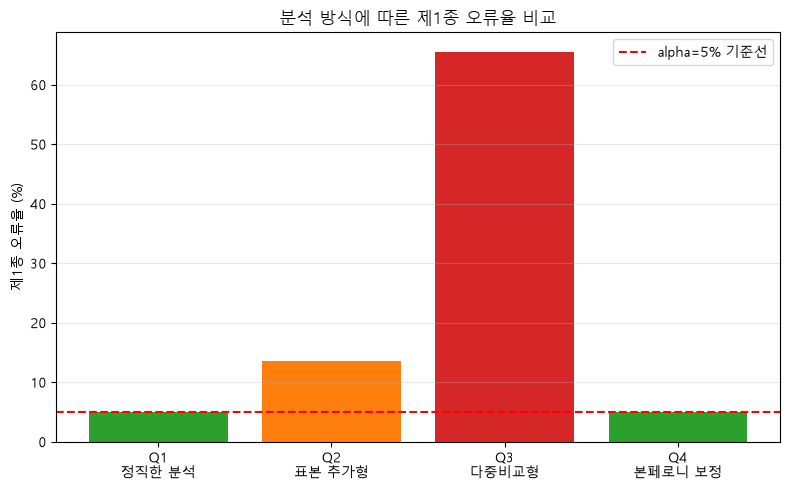

In [25]:
labels = ['Q1\n정직한 분석', 'Q2\n표본 추가형', 'Q3\n다중비교형', 'Q4\n본페로니 보정']
values = [4.9, 13.5, 65.5, 4.9]
colors = ['tab:green', 'tab:orange', 'tab:red', 'tab:green']

plt.figure(figsize=(8, 5))
plt.bar(labels, values, color=colors)
plt.axhline(5, color='red', linestyle='--', label='alpha=5% 기준선')
plt.ylabel('제1종 오류율 (%)')
plt.title('분석 방식에 따른 제1종 오류율 비교')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 💬 정리 · 결과를 말로 설명해 보기

- Q1의 값은 5%에 가까웠습니다. 이것이 뜻하는 바는 무엇인가요?
  **가설검정은 원래 무엇을 보장해 주는 도구**인가요?

- Q2와 Q3에서 오류율이 뛴 이유를 **각각** 설명해 보세요. 두 해킹의 메커니즘은 같나요, 다른가요?

- Q3의 결과는 무엇을 뜻하나요? "지표 20개를 재고 유의한 하나만 보고한다"는 연구를
  여러분은 신뢰할 수 있나요?

- 강의에 나온 **HARKing**(결과를 본 뒤에 가설을 만드는 행위)은 Q2·Q3 중 어느 쪽과 닮아 있나요?

- **사전 등록(Preregistration)**은 Q2와 Q3를 각각 어떻게 막아 주나요?
  두 해킹에 대해 따로 설명해 보세요.

- 문제 2에서 배운 '표본수 사전 설계'는 Q2를 막는 데 어떤 역할을 하나요?

<details>
<summary>(클릭) 💡 생각의 갈피</summary>

- 가설검정이 보장하는 것은 **"정해진 절차를 지켰을 때 제1종 오류가 α 이하"**입니다.
  Q1은 그 보장이 지켜지는 모습이고, Q2·Q3는 절차를 어겼을 때 보장이 무너지는 모습입니다.
  같은 t-검정 함수를 썼는데 결과가 갈렸다는 점에 주목하세요 — 문제는 도구가 아니라 **쓰는 방식**입니다.

- Q2는 **같은 가설을 여러 번 물어본** 것이고, Q3는 **여러 가설을 물어보고 하나만 골라 보고한**
  것입니다. 표현은 다르지만 둘 다 "우연에게 기회를 여러 번 준" 셈입니다.

- 동전 던지기로 생각해 보세요. 앞면이 나올 확률은 1/2이지만, **20번 던져 한 번이라도**
  앞면이 나올 확률은 거의 1입니다. Q3의 숫자가 이 계산입니다.

- 강의 9장은 **가설검증형 연구 vs 탐색형 연구**를 구분합니다. Q3처럼 지표 20개를 훑는 일 자체가
  잘못은 아닙니다. 잘못은 그것을 **가설검증형인 척 보고**하는 데 있습니다.
  탐색에서 찾은 것은 **새 데이터로 다시 확인**해야 가설검증이 됩니다.

- p-값의 한계를 다루는 또 다른 접근으로 **베이즈 인수(Bayes Factor)**가 있습니다.
  강의 9장이 "11장 학습 후 진행 예정"으로 남겨 둔 주제입니다.

</details>

In [ ]:
# 문제 3 · 정리
# 여기에 의견을 작성해주세요.

[1번 문제]
- 가설검정이 보장하는 것은 "정해진 절차를 그대로 지켰을 때, 제1종 오류율이 유의수준 α 이하로 유지된다"는 것뿐이다. Q1이 4.9%로 나온 것은 이 보장이 실제로 지켜지고 있다는 증거다. 즉 가설검정은 "진짜 차이가 있는지 확실히 알려주는 도구"가 아니라, "정직하게 한 번만 검정했을 때 우연히 속을 확률을 약속된 수준(5%)으로 묶어두는 도구"다.

[2번 문제]
- 메커니즘은 다르다. Q2(표본 추가형)는 같은 가설을 여러 번 다시 물어본 경우다. 처음 검정에서 유의하지 않아도 포기하지 않고 표본을 늘려 다시 검정하기를 최대 5번 반복하니, 그중 한 번이라도 우연히 걸릴 기회가 늘어나 오류율이 4.9%에서 13.2%로 뛰었다. Q3(다중비교형)는 서로 다른 여러 가설(지표 20개)을 동시에 물어보고 그중 하나만 골라 보고한 경우다. 각 지표가 독립적으로 5%씩 우연히 걸릴 기회를 가지므로, 20개를 다 합치면 하나라도 걸릴 확률이 65.5%까지 폭증하게된다. 표현은 다르지만 둘 다 "우연에게 기회를 여러 번 준다"는 점에서는 같은 뿌리를 공유한다.

[3번 문제]
- Q3의 65.5%는, 진짜 차이가 하나도 없는 상황에서도 이런 식으로 연구하면 열 번 중 여섯 번 이상은 "유의한 결과를 찾았다"고 잘못 보고하게 된다는 뜻이다. 동전을 20번 던지면 앞면이 한 번이라도 나올 확률이 거의 1인 것과 같은 원리다. 따라서 이런 방식으로 나온 "유의한 결과"는 신뢰할 수 없다. 그 결과가 진짜 발견인지, 아니면 20번 던져서 우연히 걸린 앞면인지 구분할 방법이 없기 때문이다.

[4번 문제]
- Q3에 더 가깝다. Q3는 여러 지표를 미리 다 재본 다음, 그중 유의했던 하나를 마치 원래부터 그것을 검증하려던 것처럼 골라서 보고하는 구조다. HARKing도 똑같이, 데이터를 이미 본 뒤에 우연히 유의했던 결과를 원래의 연구 가설이었던 것처럼 사후적으로 재구성해서 발표하는 행위다. 둘 다 여러 가능성 중 결과가 좋은 것만 골라, 처음부터 그것만 노렸던 척한다는 점이 닮아 있다.

[5번 문제]
- Q2(표본 추가형)의 경우, 사전 등록에서 표본 크기와 중단 시점을 미리 확정해두면, 결과를 보고 나서 표본을 더 모을지 말지를 임의로 정할 수 없게 된다. 그래서 유의할 때까지 계속 뽑는 시도 자체가 원천 차단된다. Q3(다중비교형)의 경우, 사전 등록에서 검정할 지표와 그 개수를 미리 명시하고 다중비교 보정(예: 본페로니)을 적용하겠다고 못 박아두면, 20개 중 하나만 골라서 보고하는 것이 불가능해지고 20개 전체에 대해 보정된 기준으로 판단해야 한다.

[6번 문제]
- 문제 2에서 배운 것처럼, 검출하고자 하는 효과크기와 목표 검정력을 바탕으로 필요한 표본수를 실험 시작 전에 미리 계산해서 고정해두면, Q2처럼 결과가 마음에 안 들 때마다 표본을 조금씩 추가하는 행위 자체가 애초에 불가능해진다. 표본수가 상수가 되는 것이다.

---

# 인과와 상관

> 상관을 인과로 착각하게 만드는 것은 무엇이며, 그것을 어떻게 걷어내는지를 봅니다.

## 문제 4 · 교란요인을 지우는 두 가지 방법 — 통제와 무작위화

`난이도 중` · `예상 30분`

**📖 상황**

- 7장 문제 1에서 이상한 것을 봤습니다. 펭귄 부리는 **전체로 보면 길수록 얇은데,
  종별로 나눠 보면 길수록 두꺼웠습니다.** 그때 "이 현상에는 이름이 붙어 있고,
  다음 시간 인과추론에서 다시 만난다"고 적어 두었습니다. **이제 그 이름을 붙입니다.**

- 원인은 **중첩요인(교란변수, Confounder)** — '종'이 부리 길이와 두께 양쪽에 영향을 주고
  있었습니다. 여기서 생겨난 가짜 음의 관계를 **허위상관(Spurious Correlation)**이라 부릅니다.

- 교란요인을 지우는 길은 두 갈래입니다.
  - **① 통제** — 층별로 나눠 보거나, 회귀식에 함께 넣기 (강의 10.3)
  - **② 무작위화** — 애초에 동전을 던져 배정하기, 즉 **무작위 통제 실험(RCT)** (강의 10.2)

- 이번 문제는 두 방법을 나란히 써 보고, **왜 무작위화가 더 강력한지** 확인합니다.

**🎯 이 문제로 배우는 것**

- 실제 데이터로 허위상관을 진단하고 통제로 걷어낸 뒤, 시뮬레이션으로 **무작위 배정의 힘**을
  확인합니다. 그리고 두 방법의 **결정적 차이**를 이해합니다.

In [28]:
# 문제 4 · 데이터 준비 (1/2) — 실행만 하세요
# 펭귄 부리 데이터: 7장 문제 1에서 봤던 그 데이터입니다.
bills = penguins.dropna(subset=['bill_length_mm', 'bill_depth_mm', 'species'])

print("분석에 사용할 데이터: %d 행\n" % len(bills))
print("종별 부리 평균 —— '종'이 두 변수 모두에 영향을 주고 있다는 단서")
print(bills.groupby('species')[['bill_length_mm', 'bill_depth_mm']].mean().round(2))

분석에 사용할 데이터: 342 행

종별 부리 평균 —— '종'이 두 변수 모두에 영향을 주고 있다는 단서
           bill_length_mm  bill_depth_mm
species                                 
Adelie              38.79          18.35
Chinstrap           48.83          18.42
Gentoo              47.50          14.98


### Q1 · 전체 데이터로 부리 길이와 두께의 관계를 회귀로 확인해 봅시다

- `bill_depth_mm`(반응변수)을 `bill_length_mm`(설명변수)으로 설명하는 **단순회귀**를 적합하세요.

- 기울기 계수와 p-값을 출력하세요.

- **이 결과만 보고했다면 어떤 결론이 되는지** 한 줄로 적으세요.

- `💡 힌트` `smf.ols(formula='...', data=bills).fit()` — 7장에서 쓴 방식과 같습니다.

- `📖 용어` **적합(fit)** — 모형의 **형태**만 정해 주면 절편과 기울기는 아직 빈칸입니다.
  그 빈칸을 데이터로부터 채워 넣는 것, 즉 흩어진 점들 사이로 **가장 잘 들어맞는 직선을 찾아내는 작업**이
  '적합'입니다. 코드에서는 `.fit()`이 그 순간이며, 메서드 이름 자체가 fit(적합)입니다.
  **"적합하세요" = "`.fit()`을 호출해 계수를 추정하세요"** 로 읽으면 됩니다.
  ('적용'과 다릅니다 — 적합이 먼저고, 적합해 둔 모형을 새 데이터에 쓰는 것이 적용입니다.)

In [29]:
# 문제 4 · Q1
# 여기에 코드를 작성해주세요.
import statsmodels.formula.api as smf

model_q1 = smf.ols(formula='bill_depth_mm ~ bill_length_mm', data=bills).fit()

slope = model_q1.params['bill_length_mm']
p_value = model_q1.pvalues['bill_length_mm']

print(f'기울기 계수: {slope:.4f}')
print(f'p-값: {p_value:.6f}')

기울기 계수: -0.0850
p-값: 0.000011


### Q2 · 종별로 층을 나눠 같은 회귀를 다시 해 봅시다

- 세 종(Adelie · Chinstrap · Gentoo) **각각에 대해** Q1과 똑같은 회귀를 적합하세요.

- 종별로 **n, 기울기 계수, p-값**을 표로 정리해 출력하세요.

- 이것은 강의 10장의 _"중학교 1·2·3학년으로 층을 나눈 후, 각 학년을 따로 해석"_ 과
  **똑같은 작업**입니다.

- `💡 힌트` `for 종, 그룹 in bills.groupby('species'):` 로 돌면서 각 그룹에 회귀를 적합하세요.

In [30]:
# 문제 4 · Q2
rows = []
for species, group in bills.groupby('species'):
    model = smf.ols(formula='bill_depth_mm ~ bill_length_mm', data=group).fit()
    rows.append({
        '종': species,
        'n': len(group),
        '기울기': model.params['bill_length_mm'],
        'p-값': model.pvalues['bill_length_mm']
    })

result_q2 = pd.DataFrame(rows)
print(result_q2.to_string(index=False))

        종   n      기울기          p-값
   Adelie 151 0.178834 6.674141e-07
Chinstrap  68 0.222212 1.525539e-09
   Gentoo 123 0.204844 1.015502e-15


### Q3 · 종을 회귀식에 함께 넣어 통제해 봅시다

- 이번엔 층을 나누지 않고, **회귀식에 '종'을 함께 넣어** 한 번에 적합하세요.

- Q1의 결과와 **기울기·p-값·R²를 나란히 출력**해 비교하세요.

- `💡 힌트` `'bill_depth_mm ~ bill_length_mm + C(species)'`
  — `C()`는 범주형 변수를 더미로 자동 변환해 줍니다.
  (주의: `C`라는 이름의 변수를 만들면 이 기능이 가려집니다)

In [31]:
# 문제 4 · Q3
model_q3 = smf.ols(formula='bill_depth_mm ~ bill_length_mm + C(species)', data=bills).fit()

print('구분           기울기        p-값          R²')
print(f"Q1 (종 통제 X)  {model_q1.params['bill_length_mm']:.4f}    {model_q1.pvalues['bill_length_mm']:.2e}    {model_q1.rsquared:.4f}")
print(f"Q3 (종 통제 O)  {model_q3.params['bill_length_mm']:.4f}    {model_q3.pvalues['bill_length_mm']:.2e}    {model_q3.rsquared:.4f}")

구분           기울기        p-값          R²
Q1 (종 통제 X)  -0.0850    1.12e-05    0.0552
Q3 (종 통제 O)  0.1999    8.66e-26    0.7690


### Q4 · 관찰연구에서 처치군과 대조군은 애초에 다릅니다

- 아래 데이터 준비 셀을 실행하면 학생 2,000명의 데이터 **두 벌**이 만들어집니다.
  같은 학생들인데 **강의 배정 방식만** 다릅니다.

- 먼저 **관찰연구(`df_obs`)**를 보세요. 성적이 좋고 열심인 학생이 스스로 신청한 상황입니다.

- ① 수강생과 비수강생의 `final_score` **단순 평균 차이**를 계산하세요.

- ② 두 집단의 **교란요인 평균**(`pre_score`, `study_hours`)도 함께 비교하세요.

- 참 효과는 **5.0점**입니다. 단순 평균 차이가 이 값과 얼마나 다른지 확인하세요.

- `💡 힌트` `df_obs.groupby('course')[['pre_score', 'study_hours', 'final_score']].mean()`

In [32]:
# 문제 4 · 데이터 준비 (2/2) — 실행만 하세요
# 같은 학생 2,000명에게 '새 온라인 강의'를 배정하는 두 가지 방식
TRUE_EFFECT = 5.0                      # 강의의 진짜 효과: 기말고사 +5점
rng = np.random.default_rng(279)
n = 2000

pre_score   = rng.normal(60, 10, n)    # 교란요인 ① 사전 성적
study_hours = rng.normal(10,  3, n)    # 교란요인 ② 주당 학습시간

# 잠재결과 — 두 교란요인은 결과(기말고사 성적)에도 직접 영향을 줍니다
Y0 = 20 + 0.7 * pre_score + 0.8 * study_hours + rng.normal(0, 5, n)  # 강의를 안 들었을 때
Y1 = Y0 + TRUE_EFFECT                                                 # 강의를 들었을 때

# (A) 관찰연구 — 성적 좋고 열심인 학생이 스스로 신청 (선택 편향)
signup_logit = -0.6 + 0.10 * (pre_score - 60) + 0.20 * (study_hours - 10)
course_obs = rng.binomial(1, 1 / (1 + np.exp(-signup_logit)))

# (B) 무작위 통제 실험 — 동전을 던져 배정
course_rct = rng.binomial(1, 0.5, n)

df_obs = pd.DataFrame({'pre_score': pre_score, 'study_hours': study_hours,
                       'course': course_obs, 'final_score': np.where(course_obs == 1, Y1, Y0)})
df_rct = pd.DataFrame({'pre_score': pre_score, 'study_hours': study_hours,
                       'course': course_rct, 'final_score': np.where(course_rct == 1, Y1, Y0)})

print("참 효과(우리가 추정해야 하는 값): %.1f점\n" % TRUE_EFFECT)
print("관찰연구 df_obs — 수강생 %d명 (%.1f%%)" % (df_obs['course'].sum(), df_obs['course'].mean()*100))
print("RCT      df_rct — 수강생 %d명 (%.1f%%)" % (df_rct['course'].sum(), df_rct['course'].mean()*100))

참 효과(우리가 추정해야 하는 값): 5.0점

관찰연구 df_obs — 수강생 751명 (37.5%)
RCT      df_rct — 수강생 1012명 (50.6%)


In [34]:
# 문제 4 · Q4
# ① 수강생 vs 비수강생 단순 평균 차이
diff_naive = (df_obs.loc[df_obs['course']==1, 'final_score'].mean()
              - df_obs.loc[df_obs['course']==0, 'final_score'].mean())
print(f'① 관찰연구 단순 평균 차이: {diff_naive:.2f}점 (참 효과 5.0점과의 차이: {diff_naive-5.0:.2f}점)')

# ② 두 집단의 교란요인 평균 비교
print(df_obs.groupby('course')[['pre_score', 'study_hours', 'final_score']].mean().round(2))

① 관찰연구 단순 평균 차이: 11.34점 (참 효과 5.0점과의 차이: 6.34점)
        pre_score  study_hours  final_score
course                                     
0           57.05         9.71        67.87
1           64.74        11.10        79.21


### Q5 · 같은 학생들을 동전 던지기로 배정하면 어떻게 될까요

- 이제 **RCT(`df_rct`)**에 대해 Q4와 **똑같은 두 가지 계산**을 하세요.

- 단순 평균 차이를 참 효과 5.0점과 비교하세요.

- 두 방식의 **교란요인 균형**을 하나의 표로 정리하면 대비가 선명해집니다.
  (행: `pre_score`, `study_hours` / 열: 관찰연구 차이, RCT 차이)

- `💡 힌트` Q4의 코드를 `df_rct`에 대해 반복하면 됩니다.
  표는 `pd.DataFrame({'관찰연구': [...], 'RCT': [...]}, index=[...])` 형태로 만들 수 있습니다.

In [35]:
# 문제 4 · Q5
# ① RCT 단순 평균 차이
diff_rct = (df_rct.loc[df_rct['course']==1, 'final_score'].mean()
            - df_rct.loc[df_rct['course']==0, 'final_score'].mean())
print(f'① RCT 단순 평균 차이: {diff_rct:.2f}점 (참 효과 5.0점과의 차이: {diff_rct-5.0:.2f}점)')

# ② 교란요인 평균 비교
print(df_rct.groupby('course')[['pre_score', 'study_hours', 'final_score']].mean().round(2))

# 교란요인 균형 비교표
diff_obs_pre  = df_obs.loc[df_obs['course']==1,'pre_score'].mean()  - df_obs.loc[df_obs['course']==0,'pre_score'].mean()
diff_obs_hour = df_obs.loc[df_obs['course']==1,'study_hours'].mean() - df_obs.loc[df_obs['course']==0,'study_hours'].mean()
diff_rct_pre  = df_rct.loc[df_rct['course']==1,'pre_score'].mean()  - df_rct.loc[df_rct['course']==0,'pre_score'].mean()
diff_rct_hour = df_rct.loc[df_rct['course']==1,'study_hours'].mean() - df_rct.loc[df_rct['course']==0,'study_hours'].mean()

balance_table = pd.DataFrame({
    '관찰연구 차이(수강생-비수강생)': [diff_obs_pre, diff_obs_hour],
    'RCT 차이(수강생-비수강생)': [diff_rct_pre, diff_rct_hour]
}, index=['pre_score', 'study_hours'])

print(balance_table.round(3))

① RCT 단순 평균 차이: 4.98점 (참 효과 5.0점과의 차이: -0.02점)
        pre_score  study_hours  final_score
course                                     
0           59.90        10.24        70.26
1           59.97        10.23        75.24
             관찰연구 차이(수강생-비수강생)  RCT 차이(수강생-비수강생)
pre_score                7.687             0.071
study_hours              1.382            -0.008


### 💬 정리 · 결과를 말로 설명해 보기

- Q1의 기울기는 **음수**인데 Q2·Q3의 기울기는 **양수**였습니다. 같은 데이터에서 부호가 뒤집힌
  이유는 무엇인가요? 이 현상의 이름은 무엇인가요?

- Q2(층별 분석)와 Q3(다중회귀)는 같은 결론을 줬습니다. **두 방법의 차이**는 무엇인가요?
  층이 아주 많아지면 어느 쪽이 유리할까요?

- Q4에서 관찰연구의 단순 비교값은 참 효과 5점과 크게 달랐습니다.
  **교란요인 균형 표를 근거로** 그 이유를 설명해 보세요.

- Q5의 RCT는 `pre_score`도 `study_hours`도 **통제하지 않았는데** 참값에 가까웠습니다.
  어떻게 이런 일이 가능한가요?

- 통제(Q3)와 무작위화(Q5)의 **결정적 차이**는 무엇인가요?
  **우리가 아직 모르는 교란요인**이 있다면 어느 쪽이 안전한가요?

- 그런데 현실에서 RCT가 늘 가능한가요? **불가능한 예를 두 개** 들어 보세요.

<details>
<summary>(클릭) 💡 생각의 갈피</summary>

- 강의 10장은 RCT를 이렇게 설명했습니다 — _"중첩요인을 확인하지 않더라도, 그 효과를 무작위를
  이용하여 무효화할 수 있으므로, 알고자 하는 변수의 효과만 추정 가능합니다."_
  Q5의 균형 표가 이 문장의 증거입니다.

- **통제는 이름을 아는 교란요인만 지웁니다.** Q3에서 우리가 지운 것은 '종' 하나뿐입니다.
  성별·서식지·측정 연도는 그대로 남아 있습니다. 그 목록이 완전하다고 누가 보장해 줄까요?

- **무작위화는 아직 이름도 모르는 교란요인까지** 두 집단에 고르게 흩뿌립니다.
  이것이 RCT를 '인과추론의 황금 표준'이라 부르는 이유입니다.

- Q2 vs Q3 — 층별 분석은 층마다 따로 결론을 주므로 층이 많아지면 각 층의 n이 작아집니다.
  다중회귀는 모든 데이터를 한 번에 쓰지만, 대신 "층마다 기울기가 같다"는 가정을 덧붙입니다.

- 마지막 질문 — 강의는 담배와 건강을 예로 듭니다. 무작위로 흡연 집단을 만들 수 있을까요?
  윤리·비용·시간이 길을 막는 이 지점에서 **다음 문제가 시작됩니다.**

</details>

In [ ]:
# 문제 4 · 정리
# 여기에 의견을 작성해주세요.

[1번 문제]
- Q1은 종이라는 변수를 무시하고 전체 데이터를 하나로 뭉쳐서 회귀를 돌렸다. 그런데 실제로는 '종'이 부리 길이와 부리 두께 양쪽에 동시에 영향을 주는 교란요인이었다. Gentoo는 부리가 길면서 얇고, Adelie는 부리가 짧으면서 두꺼운 식으로 종 간 차이가 워낙 크다 보니, 종을 구분하지 않고 전체를 보면 마치 "부리가 길수록 얇다"는 관계처럼 보인다. 하지만 종별로 나눠서 보면 오히려 부리가 길수록 두꺼운, 정반대의 관계가 나온다. 이렇게 교란요인 때문에 원래 없거나 반대 방향인 관계가 있는 것처럼 보이는 현상을 허위상관이라 부른다.

[2번 문제]
- Q2는 층마다 완전히 따로 회귀를 돌려서, 절편뿐 아니라 기울기까지 층마다 독립적으로 추정한다. Q3는 모든 데이터를 한 번에 써서 회귀를 돌리되, "층마다 절편은 다르지만 기울기는 공통"이라는 가정을 덧붙인다. 층이 아주 많아지면 Q2 방식은 각 층에 들어가는 표본 수(n)가 작아져 추정이 불안정해지지만, Q3는 모든 데이터를 함께 사용하므로 표본이 부족해지는 문제를 피할 수 있어 다중회귀 쪽이 더 유리하다.

[3번 문제]
- 교란요인 균형 표를 보면, 관찰연구에서 수강생과 비수강생의 pre_score 차이는 7.687점, study_hours 차이는 1.382시간으로 두 집단이 애초에 크게 달랐다. 성적 좋고 열심인 학생이 스스로 강의를 신청했기 때문이다. 이 두 교란요인은 최종 성적에도 직접 영향을 주므로, 수강생과 비수강생의 성적 차이 11.34점 안에는 강의의 진짜 효과(5점)뿐 아니라 원래부터 존재했던 학생 간 차이(약 6.34점)까지 섞여 들어갔다. 그 결과 단순 비교값이 참 효과보다 크게 부풀려졌다.

[4번 문제]
- RCT에서는 수강 여부를 pre_score나 study_hours와 무관하게 순수한 동전 던지기(50% 확률)로 정했다. 그 결과 교란요인 균형 표에서 보듯 수강생과 비수강생의 pre_score 차이는 0.071점, study_hours 차이는 -0.008시간으로 거의 0에 가까웠다. 무작위 배정이 두 교란요인을 두 집단에 골고루 흩어 놓았기 때문에, 회귀나 층화 같은 별도의 통제 절차 없이도 두 집단이 애초에 동등해졌고, 그래서 단순 평균 차이만으로도 참 효과에 근접한 값(4.98점)을 얻을 수 있었다.

[5번 문제]
- 통제(Q3)는 우리가 이름을 알고 있는 교란요인만 지울 수 있다. Q3에서 지운 것은 '종' 하나뿐이며, 성별·서식지·측정 연도처럼 우리가 미처 생각하지 못한 다른 교란요인은 그대로 남아 있을 수 있다. 반면 무작위화(Q5)는 이름을 아는 교란요인은 물론, 아직 존재조차 모르는 교란요인까지 두 집단에 고르게 흩뿌려 균형을 맞춘다. 따라서 우리가 미처 파악하지 못한 교란요인이 있을 가능성을 고려하면, 무작위화 쪽이 훨씬 안전할 것이다.

[6번 문제]
- 현실에서는 RCT가 늘 가능한 것은 아니다. 예를 들어 흡연이 건강에 미치는 영향을 알아보기 위해 사람들을 무작위로 흡연 집단과 비흡연 집단에 배정할 수는 없다. 이는 비윤리적이며 실행할 수도 없다. 또 다른 예로 소득 수준이나 학력이 특정 결과에 미치는 영향을 연구할 때, 사람들의 소득이나 학력을 실험자가 무작위로 배정할 수는 없다. 이런 특성은 이미 개인에게 고정되어 있거나, 배정하려면 막대한 비용과 시간, 윤리적 문제가 따르기 때문에 RCT 대신 관찰연구와 통제 기법에 의존할 수밖에 없다.

## 문제 5 · 미니 프로젝트 — 실험할 수 없을 때

`난이도 상` · `예상 40분`

**📖 상황**

- 문제 4에서 확인했습니다. 무작위 배정만 되면 인과효과는 **단순 평균 차이**로 구해집니다.
  문제는 **대부분의 현실에서 무작위 배정이 불가능**하다는 것입니다.

- 그래서 관찰 데이터만 놓고 인과효과에 다가가는 방법들이 있습니다. 강의 10.3의 두 가지를 씁니다.

- **① 경향점수 짝짓기(PSM)** — 처치를 받을 '경향'이 비슷한 사람끼리 짝지어
  **'통계적 쌍둥이'** 집단을 만듭니다.

- **② 이중차분법(DiD)** — 시간축을 도입해, 통제군의 변화를 '정책이 없었다면 일어났을 변화'로
  삼고 실험군의 변화에서 빼냅니다.

- 두 방법 모두 **가정 위에 서 있습니다.** 그래서 이 문제의 진짜 목표는 추정값을 구하는 것이 아니라,
  **그 가정을 검증하는 절차까지 해 보는 것**입니다.

**🎯 이 문제로 배우는 것**

- PSM으로 선택편향을 보정하고 **공변량 균형**으로 검증하며,
  DiD로 정책효과를 추정하고 **평행추세 확인·플라시보 검정**으로 반증을 시도합니다.

In [37]:
# 문제 5 · 데이터 준비 (1/2) — 실행만 하세요
# 문제 4에서 만든 관찰연구 데이터(df_obs)를 그대로 이어서 씁니다.
print("관찰연구 데이터 df_obs: %d행" % len(df_obs))
print("  수강생 %d명 / 비수강생 %d명" % ((df_obs['course']==1).sum(), (df_obs['course']==0).sum()))
print("  단순 평균 비교(문제 4 Q4): %+.2f점" % (
    df_obs.loc[df_obs['course']==1, 'final_score'].mean()
    - df_obs.loc[df_obs['course']==0, 'final_score'].mean()))
print("  우리가 되찾아야 하는 참 효과: %+.1f점" % TRUE_EFFECT)

관찰연구 데이터 df_obs: 2000행
  수강생 751명 / 비수강생 1249명
  단순 평균 비교(문제 4 Q4): +11.34점
  우리가 되찾아야 하는 참 효과: +5.0점


### Q1 · 경향점수를 추정해 봅시다

- **로지스틱 회귀**로 각 학생이 강의를 신청할 확률(= 경향점수)을 추정하세요.
  설명변수는 `pre_score`, `study_hours`이고 반응변수는 `course`입니다.

- 추정한 경향점수를 `df_obs['ps']` 열에 저장하세요. **Q2·Q3에서 계속 씁니다.**

- 수강생과 비수강생의 **경향점수 분포를 히스토그램으로 겹쳐 그려**,
  두 집단이 겹치는 구간이 있는지 확인하세요. (겹치는 구간이 있어야 짝을 찾을 수 있습니다)

- `💡 힌트` `sm.Logit(y, sm.add_constant(X)).fit(disp=0)` 으로 적합하고 `.predict()`로 확률을 얻습니다.
  히스토그램은 `plt.hist(..., alpha=0.5, label=...)`를 두 번 호출하면 겹쳐 그려집니다.

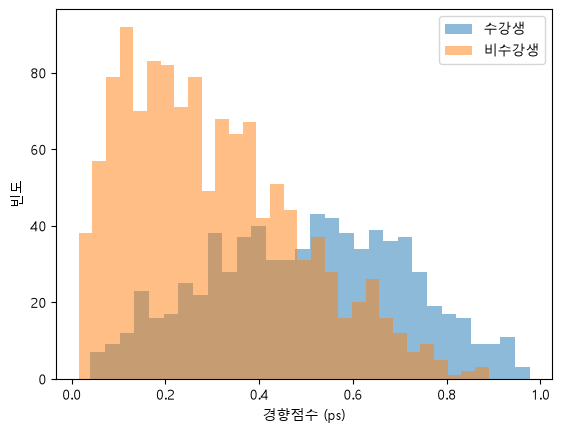

In [38]:
# 문제 5 · Q1
X = df_obs[['pre_score', 'study_hours']]
y = df_obs['course']

logit_model = sm.Logit(y, sm.add_constant(X)).fit(disp=0)
df_obs['ps'] = logit_model.predict(sm.add_constant(X))

plt.hist(df_obs.loc[df_obs['course']==1, 'ps'], bins=30, alpha=0.5, label='수강생')
plt.hist(df_obs.loc[df_obs['course']==0, 'ps'], bins=30, alpha=0.5, label='비수강생')
plt.xlabel('경향점수 (ps)')
plt.ylabel('빈도')
plt.legend()
plt.show()

### Q2 · 1:1 짝짓기로 ATT를 추정해 봅시다

- 수강생(실험군) 한 명마다, **경향점수가 가장 가까운 비수강생(대조군) 1명**을 찾아 짝지으세요.

- 짝지어진 두 집단의 `final_score` 평균 차이를 계산하세요.
  이것이 **ATT**(처치집단에 대한 평균 처치효과)입니다.

- 세 값을 **나란히 출력**해 비교하세요.
  **① 단순 평균 비교(문제 4) ② PSM 이후 ATT ③ 참 효과 5.0점**

- `💡 힌트` `NearestNeighbors(n_neighbors=1).fit(대조군[['ps']])` 로 학습한 뒤
  `.kneighbors(실험군[['ps']])`를 호출하면 `(거리, 인덱스)`를 돌려줍니다.
  인덱스로 대조군을 골라낼 때는 `대조군.iloc[indices.flatten()]`를 씁니다.

In [39]:
# 문제 5 · Q2
from sklearn.neighbors import NearestNeighbors

treated = df_obs[df_obs['course'] == 1].reset_index(drop=True)
control = df_obs[df_obs['course'] == 0].reset_index(drop=True)

nn = NearestNeighbors(n_neighbors=1).fit(control[['ps']])
distances, indices = nn.kneighbors(treated[['ps']])
matched_control = control.iloc[indices.flatten()].reset_index(drop=True)

att = treated['final_score'].mean() - matched_control['final_score'].mean()

### Q3 · 짝짓기가 잘 됐는지 검증해 봅시다 — 공변량 균형

- 짝짓기는 **잘 됐다고 가정하면 안 되고, 확인해야 합니다.**
  이 확인 절차를 **공변량 균형(Covariate Balance)** 점검이라 부릅니다.

- `pre_score`와 `study_hours`에 대해, 두 집단의 평균 차이를
  **짝짓기 전 / 짝짓기 후**로 나누어 표로 만드세요.

- 짝짓기 후 차이가 0에 가까워졌다면 성공입니다.

- `💡 힌트` 표는 `pd.DataFrame({'짝짓기 전': [...], '짝짓기 후': [...]}, index=['pre_score', 'study_hours'])`

In [41]:
# 문제 5 · Q3
control_all = df_obs[df_obs['course'] == 0]

before = {
    'pre_score': treated['pre_score'].mean() - control_all['pre_score'].mean(),
    'study_hours': treated['study_hours'].mean() - control_all['study_hours'].mean()
}
after = {
    'pre_score': treated['pre_score'].mean() - matched_control['pre_score'].mean(),
    'study_hours': treated['study_hours'].mean() - matched_control['study_hours'].mean()
}

balance_table = pd.DataFrame({
    '짝짓기 전': [before['pre_score'], before['study_hours']],
    '짝짓기 후': [after['pre_score'], after['study_hours']]
}, index=['pre_score', 'study_hours'])
print(balance_table.round(3))

             짝짓기 전  짝짓기 후
pre_score    7.687  0.074
study_hours  1.382  0.025


### Q4 · DiD — 평행추세 가정을 **먼저** 확인해 봅시다

- 아래 데이터 준비 셀을 실행하면 서울·부산의 **2020~2025년 패널 데이터**가 만들어집니다.
  무료 공공 와이파이 정책은 **2024년 서울에만** 시행되었습니다.

- DiD를 계산하기 **전에** 가정을 확인합니다. **정책 시행 이전(2020~2023)만 잘라서**
  두 도시의 연도별 평균 데이터 사용량을 **꺾은선 그래프**로 그리세요.

- 연도별 **두 도시의 격차**(서울 − 부산)도 숫자로 출력하세요.

- 격차가 일정하게 유지되고 있다면, 평행추세 가정을 믿을 만합니다.

- `💡 힌트` `sns.lineplot(data=..., x='year', y='data_usage', hue='city', marker='o')`
  격차는 `.groupby(['year','city'])['data_usage'].mean().unstack()` 후 두 열을 빼면 구할 수 있습니다.

In [42]:
# 문제 5 · 데이터 준비 (2/2) — 실행만 하세요
# 서울(실험군) / 부산(통제군)의 1인당 월 데이터 사용량(GB), 2020~2025년
POLICY_YEAR = 2024        # 서울시가 무료 공공 와이파이를 도입한 해
TRUE_DID    = 4.0         # 정책의 진짜 효과: +4 GB
rng = np.random.default_rng(2024)

records = []
for city, baseline, is_seoul in [('서울', 15.0, 1), ('부산', 10.0, 0)]:
    for person in range(300):
        person_effect = rng.normal(0, 2.0)                  # 사람마다 타고난 사용량 차이
        for year in range(2020, 2026):
            time_trend = 1.5 * (year - 2020)                # 두 도시에 똑같이 작용하는 시간 추세
            policy = TRUE_DID if (is_seoul and year >= POLICY_YEAR) else 0.0
            records.append((city, is_seoul, person + is_seoul * 300, year,
                            baseline + person_effect + time_trend + policy + rng.normal(0, 1.0)))

panel = pd.DataFrame(records, columns=['city', 'is_seoul', 'person_id', 'year', 'data_usage'])

print("패널 데이터: %d행 (도시 2 × 300명 × 6년)" % len(panel))
print("정책 시행: %d년, 서울만  /  참 효과: +%.1f GB\n" % (POLICY_YEAR, TRUE_DID))
print(panel.groupby(['year', 'city'])['data_usage'].mean().unstack().round(2))

패널 데이터: 3600행 (도시 2 × 300명 × 6년)
정책 시행: 2024년, 서울만  /  참 효과: +4.0 GB

city     부산     서울
year              
2020  10.16  14.69
2021  11.54  16.27
2022  13.08  17.71
2023  14.60  19.22
2024  16.11  24.74
2025  17.59  26.36


city     부산     서울  격차(서울-부산)
year                         
2020  10.16  14.69       4.53
2021  11.54  16.27       4.73
2022  13.08  17.71       4.63
2023  14.60  19.22       4.63


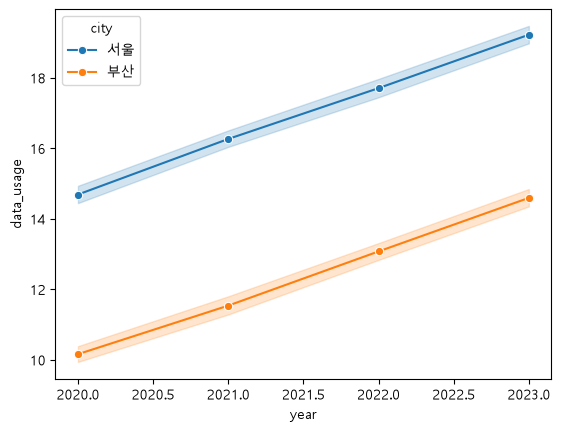

In [43]:
# 문제 5 · Q4
pre_policy = panel[panel['year'] < POLICY_YEAR]
sns.lineplot(data=pre_policy, x='year', y='data_usage', hue='city', marker='o')

gap = pre_policy.groupby(['year','city'])['data_usage'].mean().unstack()
gap['격차(서울-부산)'] = gap['서울'] - gap['부산']
print(gap.round(2))

### Q5 · 2×2 DiD 회귀로 정책효과를 추정해 봅시다

- 정책 **직전 해(2023)**와 **직후 해(2024)**만 사용합니다.

- `is_post`(2024년이면 1) 변수를 만들고, 다음 세 항이 들어간 회귀를 적합하세요.
  **`is_seoul` + `is_post` + 두 변수의 상호작용**

- 결과표를 출력하고, **계수 세 개가 각각 무엇을 재고 있는지** 주석에 적으세요.

- 상호작용항 계수를 참 효과 **+4.0 GB**와 비교하세요.

- `💡 힌트` `smf.ols('data_usage ~ is_seoul * is_post', data=...)`
  — 수식의 `*`는 두 주효과와 상호작용을 **한꺼번에** 넣어 줍니다.
  결과표에서 상호작용항의 이름은 `is_seoul:is_post`입니다.

In [ ]:
# 문제 5 · Q5
# 계수 세 개의 의미
# is_seoul의 의미: 정책 시행 전(2023) 기준, 서울과 부산의 원래 격차 (4.63)
# is_post의 의미: 부산(대조군) 기준, 2023→2024로 넘어가며 자연스럽게 늘어난 사용량 (1.52)
# is_seoul:is_post의 의미: 서울이 '정책 때문에' 추가로 더 늘어난 부분 = DiD 추정치 (4.01)

df_did = panel[panel['year'].isin([2023, 2024])].copy()
df_did['is_post'] = (df_did['year'] == 2024).astype(int)

model_did = smf.ols('data_usage ~ is_seoul * is_post', data=df_did).fit()
print(model_did.summary().tables[1])

                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           14.5950      0.128    114.112      0.000      14.344      14.846
is_seoul             4.6277      0.181     25.584      0.000       4.273       4.983
is_post              1.5155      0.181      8.378      0.000       1.161       1.870
is_seoul:is_post     4.0064      0.256     15.662      0.000       3.505       4.508


### Q6 · 플라시보 검정으로 스스로 반증을 시도해 봅시다

- 우리 추정치를 **의심해 봅니다.** 정책이 **없었던 구간**에 똑같은 DiD를 적용하면
  효과가 0으로 나와야 정상입니다.

- **2022년 vs 2023년**(둘 다 정책 이전)으로 Q5와 똑같은 회귀를 돌리세요.

- 상호작용항 계수와 p-값을 출력하고, **검정을 통과했는지** 문장으로 판정하세요.

- 여기서 만약 유의한 효과가 나왔다면 **무엇을 의심해야 하는지**도 함께 적으세요.

- `💡 힌트` Q5의 코드에서 연도만 바꾸면 됩니다. `is_post`는 이제 2023년이면 1입니다.

# 문제 5 · Q6
df_placebo = panel[panel['year'].isin([2022, 2023])].copy()
df_placebo['is_post'] = (df_placebo['year'] == 2023).astype(int)

model_placebo = smf.ols('data_usage ~ is_seoul * is_post', data=df_placebo).fit()
coef = model_placebo.params['is_seoul:is_post']
p_val = model_placebo.pvalues['is_seoul:is_post']
coef

### Q7 · 보고 문장으로 정리해 봅시다

- 지금까지의 결과를 종합해, 두 분석을 보고서에 어떻게 적을지 **각각 한 문장**으로 쓰세요.

- 숫자만 적지 말고 **어떤 가정 위에서 얻은 값인지, 어떻게 검증했는지**를 함께 담으세요.

In [ ]:
# 문제 5 · Q7
# PSM 보고 문장 (추정값 + 사용한 방법 + 균형 검증 결과 + 남은 한계):
#
# 경향점수 매칭(관측된 교란요인 pre_score, study_hours에 한해 두 집단이 동등하다는 가정 하에)을 통해
# 강의 수강생과 경향점수가 가장 가까운 비수강생을 1:1로 짝지은 결과, 처치효과(ATT)는 +5.02점으로
# 추정되었다. 짝짓기 전 두 집단의 pre_score(7.687), study_hours(1.382) 차이가 짝짓기 후 각각
# 0.074, 0.025로 크게 줄어들어 공변량 균형이 확인되었으나, 관측하지 못한 다른 교란요인이 존재할
# 경우 이 추정치는 여전히 편향될 수 있다는 한계가 남는다.
#
# DiD 보고 문장 (추정값 + 사용한 방법 + 평행추세 확인 + 플라시보 검정 결과):
#
# 이중차분법(정책이 없었다면 서울과 부산의 데이터 사용량 격차가 시간에 따라 일정하게 유지되었을
# 것이라는 평행추세 가정 하에)을 통해 무료 공공 와이파이 정책의 효과를 추정한 결과, 정책 시행
# 직전(2023)과 직후(2024)의 격차 변화는 +4.01 GB였다. 정책 시행 이전 4개년(2020~2023) 동안 두
# 도시의 격차가 4.5~4.7 GB 사이로 안정적으로 유지되어 평행추세 가정이 뒷받침되었고, 정책이 없었던
# 구간(2022 vs 2023)에 동일한 분석을 적용한 플라시보 검정에서도 유의한 효과가 나타나지 않아(p=0.99)
# 이 추정치가 우연이 아닌 정책의 실제 효과일 가능성이 뒷받침되었다.

### 💬 정리 · 결과를 말로 설명해 보기

- Q2의 ATT는 참값 5점에 가까웠고, 문제 4의 단순 비교는 크게 벗어났습니다.
  **PSM이 한 일**을 한 문장으로 설명해 보세요.

- Q3의 균형 표에서 짝짓기 후 교란요인 차이는 어떻게 변했나요?
  만약 짝짓기 **후에도** 차이가 크게 남아 있었다면 어떻게 해야 할까요?

- PSM은 **경향점수 모형에 넣은 변수만** 균형을 맞춥니다. 만약 관측하지 못한 교란요인
  (예: 학생의 타고난 이해력)이 있다면, Q2의 ATT를 인과효과라고 부를 수 있을까요?
  **문제 4의 RCT와 비교**해서 답해 보세요.

- Q4에서 정책 이전 4년간 두 도시의 격차는 거의 일정했습니다. 이것이 DiD의 **어떤 가정**을
  지지하나요? 만약 이전부터 격차가 벌어지고 있었다면 Q5의 계수를 어떻게 읽어야 할까요?

- Q5의 상호작용항이 왜 정책효과인가요? 네 개 평균값을 직접 계산해
  `(A₂ − A₁) − (B₂ − B₁)`과 일치하는지 확인해 보세요.

- Q6의 플라시보 검정이 만약 **유의하게** 나왔다면, 우리는 무엇을 의심해야 하나요?

- PSM과 DiD는 각각 어떤 상황에 쓰는 도구인가요? 두 방법의 **데이터 요구조건**
  (단면 데이터 vs 패널 데이터)은 어떻게 다른가요?

<details>
<summary>(클릭) 💡 생각의 갈피</summary>

- 강의 10장은 DiD의 인과효과를 이렇게 적었습니다 —
  _"인과 효과 = ΔA − ΔB = (A₂ − A₁) − (B₂ − B₁)"_.
  Q5의 상호작용항 계수를 이 식과 손으로 맞춰 보면 **소수점까지 정확히 일치**합니다.
  회귀는 이 뺄셈을 대신 해 주는 도구일 뿐입니다.

- 강의 10장은 평행추세에 대해 이렇게 덧붙였습니다 — _"이 가정이 맞는지 확인하려면, 정책이
  시행되기 이전 여러 시점의 데이터를 그래프로 그려보아야 합니다."_ Q4가 정확히 그 작업입니다.
  시점이 두 개뿐이라면 이 확인 자체가 **불가능**하다는 점에 주목하세요.

- 플라시보 검정의 논리는 **"효과가 없어야 할 곳에서 효과가 나오면 방법이 틀렸다"**입니다.
  자기 결론을 스스로 반증하려 드는 습관이 통계에서 이런 모양으로 나타납니다.
  통과했다고 해서 방법이 옳음이 증명된 것은 아니라는 점도 함께 기억해 두세요.

- 세 번째 질문이 이 실습 전체의 결론입니다 — **PSM·DiD는 RCT의 대체품이 아닙니다.**
  무작위화가 자동으로 해 주던 일을, **가정을 명시적으로 걸고** 대신 해내는 차선책입니다.
  그래서 "어떤 가정을 걸었는지" 말할 수 없다면 그 추정치는 쓸 수 없습니다.

- 마지막 질문 — 시간축이 없는 데이터에서는 어느 방법을 쓸 수 없나요?
  반대로, 처치 시점이 명확한 정책이라면 어느 쪽이 더 강력한가요?

- 이 문제에서 다루지 못한 준실험 방법으로 **회귀 불연속 설계(RDD)**가 있습니다.
  "커트라인 바로 위/아래는 거의 같은 사람들"이라는 발상을 쓰는 방법으로,
  기준점이 존재하는 정책(장학금 커트라인, 정년 등)에서 강력하게 작동합니다.

</details>

In [ ]:
# 문제 5 · 정리
# 여기에 의견을 작성해주세요.

[1번 문제]
- PSM은 pre_score와 study_hours가 비슷한(경향점수가 비슷한) 수강생과 비수강생을 짝지어 "통계적 쌍둥이" 집단을 만듦으로써, 단순 비교에 섞여 있던 선택 편향(원래 성적 좋고 열심인 학생이 수강했다는 차이)을 걷어내고 강의 자체의 효과만 남긴 것이다.

[2번 문제]
- 짝짓기 전 pre_score 차이는 7.687, study_hours 차이는 1.382였으나, 짝짓기 후에는 각각 0.074, 0.025로 0에 가깝게 줄어들었다. 만약 짝짓기 후에도 차이가 크게 남아 있었다면, 그 짝짓기는 실패한 것으로 보고 결과를 신뢰해서는 안 된다. 이 경우 경향점수 모형에 변수를 더 추가하거나, 거리 제한을 두어 너무 먼 짝은 제외하거나, 공통지지영역 밖의 관측치를 아예 분석에서 빼는 등의 조치를 취해야 한다.

[3번 문제]
- 부를 수 없다. PSM은 모형에 넣은 변수(pre_score, study_hours)에 대해서만 두 집단을 비슷하게 맞춰줄 뿐, 모형에 넣지 않은 변수는 전혀 균형을 보장하지 않는다. 만약 이해력이 실제로 수강 여부와 성적 모두에 영향을 준다면, Q2의 ATT에는 여전히 편향이 남아 있을 수 있다. 반면 문제 4의 RCT는 무작위 배정을 통해 우리가 이름조차 모르는 교란요인까지 두 집단에 고르게 흩어 놓으므로, 관측되지 않은 교란요인의 존재 여부와 무관하게 인과효과를 안전하게 추정할 수 있다.(더 조음)

[4번 문제]
- 이는 DiD의 핵심 가정인 평행추세 가정을 지지한다. "정책이 없었다면 두 도시의 격차가 시간에 따라 그대로 유지되었을 것이다"라는 전제가 실제 데이터로 뒷받침된 것이다. 만약 이전부터 격차가 점점 벌어지고 있었다면, Q5의 상호작용항 계수는 정책의 순수한 효과가 아니라 원래부터 존재하던 추세 차이까지 섞인 값으로 읽어야 하며, 정책 효과가 과대 또는 과소 추정되었을 가능성을 의심해야 한다.

[5번 문제]
- 직접 계산한 결과, 서울(A1=19.2227, A2=24.7446)과 부산(B1=14.5950, B2=16.1105)의 네 평균값으로 (A2-A1)-(B2-B1)을 구하면 4.0064가 나오며, 이는 회귀의 상호작용항 계수(4.0064)와 정확히 일치한다. 상호작용항이 정책효과인 이유는, (A2-A1)이 서울의 전체 변화량(정책효과+시간추세)이고 (B2-B1)이 부산의 순수한 시간추세 변화량이므로, 그 차이를 구하면 공통된 시간추세가 상쇄되고 정책만의 순효과만 남기 때문이다.

[6번 문제]
- 정책이 없었던 구간에서 유의한 효과가 나왔다면, 이는 평행추세 가정 자체가 틀렸거나, 서울과 부산 사이에 정책과 무관한 다른 시간 가변적 요인(예를 들면, 다른 통신 인프라 변화, 지역별 경제 충격 등)이 존재했을 가능성을 의심해야 한다. 이 경우 Q5에서 얻은 +4.0 GB라는 추정치도 순수한 정책효과가 아니라 이런 교란된 추세가 섞여 들어간 값일 수 있으므로 신뢰하기 어렵다.

[7번 문제]
- PSM은 한 시점에서 관측된 여러 변수(공변량)를 바탕으로 처치군과 대조군을 비슷하게 짝지어 비교하는 방법으로, 시간축이 없는 단면 데이터만으로도 적용할 수 있다. 반면 DiD는 처치 전후 시점의 변화를 비교하는 방법이므로, 같은 대상(또는 집단)을 여러 시점에 걸쳐 추적한 패널 데이터가 반드시 필요하다. 즉 PSM은 "지금 이 순간의 특성이 비슷한 사람끼리 비교"하는 방법이고, DiD는 "시간에 따른 변화의 차이"를 비교하는 방법이다.